In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils
import paths as p

# add group and cohort info to log

In [10]:
sessions_all_raw = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_official_raw.csv'), index_col=0)

In [13]:
group_dict = {
  "s": ["RZ034", "RZ035", "RZ036",
    "RZ047", "RZ048", "RZ049", "RZ050", "RZ051",
    "RZ061", "RZ062", "RZ063", "RZ064", "RZ069", "RZ070", "RZ071", "RZ072"],
  "l": ["RZ037", "RZ038", "RZ039",
    "RZ052", "RZ053", "RZ054", "RZ055", "RZ056",
    "RZ057", "RZ058", "RZ059", "RZ060", "RZ065", "RZ066", "RZ067", "RZ068"]
    }
cohort_dict = {
    '5':['RZ034', 'RZ036', 'RZ037', 'RZ038', 'RZ039'],
    '6':['RZ047', 'RZ049','RZ050', 'RZ051', 'RZ052', 'RZ053', 'RZ055'],
    '7': ['RZ057', 'RZ058', 'RZ059', 'RZ060', 'RZ061', 'RZ062', 'RZ063', 'RZ064',
          'RZ065', 'RZ066', 'RZ067', 'RZ068', 'RZ069', 'RZ070', 'RZ071', 'RZ072']
}

In [14]:
# Create a mapping from mouse name to group label
mouse_to_group = {mouse: group for group, mice in group_dict.items() for mouse in mice}
mouse_to_cohort = {mouse: cohort for cohort, mice in cohort_dict.items() for mouse in mice}

# Add the 'group' column to sessions_all_raw
sessions_all_raw['group'] = sessions_all_raw['mouse'].map(mouse_to_group)
sessions_all_raw['cohort'] = sessions_all_raw['mouse'].map(mouse_to_cohort)

In [15]:
sessions_all_raw

,date,mouse,insertion_number,region,potential problems,sorting notes,First_X_Column,datetime,paramset_idx,num_units,id,group,cohort
2,2024-07-13,RZ034,1,str,NaN,should be all good now,Done,2024-07-13 12:58:26,101,47,RZ034_2024-07-13_str,s,5
4,2024-07-14,RZ034,1,str,NaN,NaN,Done,2024-07-14 12:52:46,101,31,RZ034_2024-07-14_str,s,5
0,2024-07-12,RZ036,0,v1,NaN,NaN,Done,2024-07-12 12:50:31,101,15,RZ036_2024-07-12_v1,s,5
1,2024-07-12,RZ036,1,str,NaN,NaN,Done,2024-07-12 12:50:31,101,45,RZ036_2024-07-12_str,s,5
3,2024-07-13,RZ036,1,str,NaN,NaN,Done,2024-07-13 14:29:03,101,30,RZ036_2024-07-13_str,s,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,2025-02-21,RZ065,1,str,NaN,NaN,Done,2025-02-21 11:15:15,101,19,RZ065_2025-02-21_str,l,7
50,2025-02-21,RZ065,0,v1,NaN,"no bug, new phy",Done,2025-02-21 11:15:15,101,27,RZ065_2025-02-21_v1,l,7
49,2025-02-20,RZ065,0,v1,NaN,missing cluster_si_unit_id.tsv. curation delet...,Done,2025-02-20 12:02:05,101,57,RZ065_2025-02-20_v1,l,7
48,2025-02-14,RZ070,1,str,NaN,NaN,Done,2025-02-14 11:03:49,101,1,RZ070_2025-02-14_str,s,7


# add session performance for filtering

In [26]:
def get_session_length(trials):
    session_start_time = trials['event_start_time'].iloc[0]
    session_end_time = trials['event_end_time'].iloc[-1]
    session_length = session_end_time - session_start_time
    return session_length

def add_session_performance(sessions_all_raw):
    session_performance_list = []
    for _, session_info in sessions_all_raw.iterrows():
        session_id = session_info['id']
        _, trials, _ = utils.get_session_data(session_id)
        
        num_trials = len(trials)
        num_missed = trials.missed.sum()
        percent_missed = num_missed / num_trials * 100
        num_bg_penalty = num_bg_penalty = (trials['num_bg_repeat'] > 0).sum()
        percent_bg_penalty = num_bg_penalty / num_trials * 100

        session_performance_dict = {
            'id': session_id,
            'length': get_session_length(trials),
            'num_trials': num_trials,
            'num_missed': num_missed,
            'percent_missed': percent_missed,
            'num_bg_penalty': num_bg_penalty,
            'percent_bg_penalty': percent_bg_penalty,
            'wait_length_mean': trials.wait_length.mean()
        }
        session_performance_list.append(session_performance_dict)
    session_performance = pd.DataFrame(session_performance_list)
    session_performance_log = pd.merge(sessions_all_raw, session_performance)
    return session_performance_log

In [27]:
sessions_all = add_session_performance(sessions_all_raw)
sessions_all.to_csv(os.path.join(p.LOGS_DIR, 'sessions_all.csv'))

In [28]:
sessions_all

,date,mouse,insertion_number,region,potential problems,sorting notes,First_X_Column,datetime,paramset_idx,num_units,id,group,cohort,length,num_trials,num_missed,percent_missed,num_bg_penalty,percent_bg_penalty,wait_length_mean
0,2024-07-13,RZ034,1,str,NaN,should be all good now,Done,2024-07-13 12:58:26,101,47,RZ034_2024-07-13_str,s,5,2443.503482,328,0,0.000000,29,8.841463,3.317166
1,2024-07-14,RZ034,1,str,NaN,NaN,Done,2024-07-14 12:52:46,101,31,RZ034_2024-07-14_str,s,5,2832.875992,408,0,0.000000,50,12.254902,2.804475
2,2024-07-12,RZ036,0,v1,NaN,NaN,Done,2024-07-12 12:50:31,101,15,RZ036_2024-07-12_v1,s,5,3274.883860,299,3,1.003344,95,31.772575,6.628682
3,2024-07-12,RZ036,1,str,NaN,NaN,Done,2024-07-12 12:50:31,101,45,RZ036_2024-07-12_str,s,5,3274.883860,299,3,1.003344,95,31.772575,6.628682
4,2024-07-13,RZ036,1,str,NaN,NaN,Done,2024-07-13 14:29:03,101,30,RZ036_2024-07-13_str,s,5,4400.303239,295,15,5.084746,68,23.050847,10.838219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2025-02-21,RZ065,1,str,NaN,NaN,Done,2025-02-21 11:15:15,101,19,RZ065_2025-02-21_str,l,7,3731.853914,302,0,0.000000,116,38.410596,3.075755
92,2025-02-21,RZ065,0,v1,NaN,"no bug, new phy",Done,2025-02-21 11:15:15,101,27,RZ065_2025-02-21_v1,l,7,3731.853914,302,0,0.000000,116,38.410596,3.075755
93,2025-02-20,RZ065,0,v1,NaN,missing cluster_si_unit_id.tsv. curation delet...,Done,2025-02-20 12:02:05,101,57,RZ065_2025-02-20_v1,l,7,3086.800761,217,0,0.000000,99,45.622120,5.559549
94,2025-02-14,RZ070,1,str,NaN,NaN,Done,2025-02-14 11:03:49,101,1,RZ070_2025-02-14_str,s,7,2461.534747,342,5,1.461988,114,33.333333,2.960163


Text(0.5, 1.0, 'Session Length Distribution')

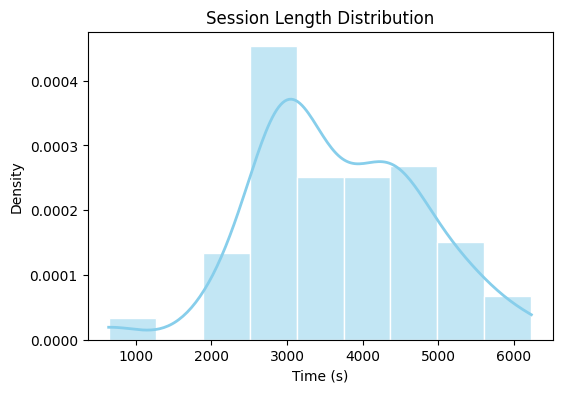

In [30]:
plt.figure(figsize=(6, 4))
ax = sns.histplot(
    data=sessions_all['length'],
    kde=True,          # Adds KDE trend line
    stat="density",    # Normalizes histogram to match KDE scale
    bins="auto",       # Auto-selects bin size (or set manually, e.g., bins=30)
    color="skyblue",   # Histogram color
    edgecolor="white", # Edge color for bars
    line_kws={"color": "red", "lw": 2}  # KDE line style
)

# Labels & title
plt.xlabel('Time (s)')
plt.ylabel('Density')
plt.title('Session Length Distribution')

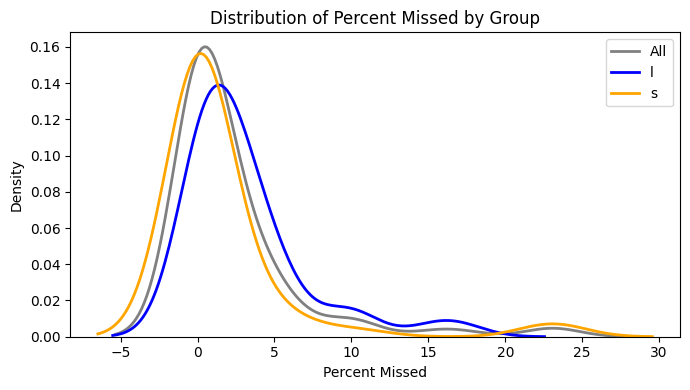

In [31]:
plt.figure(figsize=(7, 4))
sns.kdeplot(
    data=sessions_all,
    x="percent_missed",
    label="All",
    color="gray",
    linewidth=2,
)
sns.kdeplot(
    data=sessions_all[sessions_all["group"] == "l"],
    x="percent_missed",
    label="l",
    color="blue",
    linewidth=2,
)
sns.kdeplot(
    data=sessions_all[sessions_all["group"] == "s"],
    x="percent_missed",
    label="s",
    color="orange",
    linewidth=2,
)
plt.xlabel("Percent Missed")
plt.ylabel("Density")
plt.title("Distribution of Percent Missed by Group")
plt.legend()
plt.tight_layout()

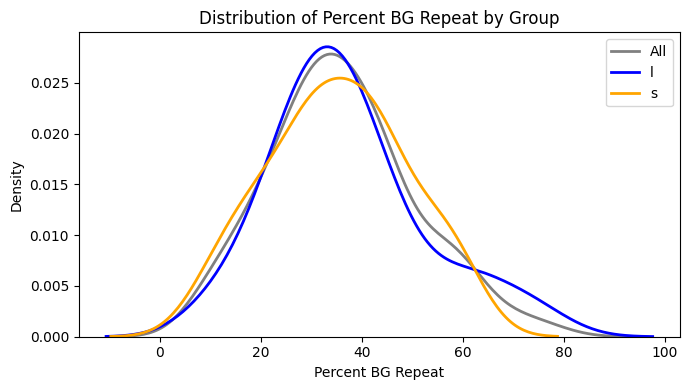

In [32]:
plt.figure(figsize=(7, 4))
sns.kdeplot(
    data=sessions_all,
    x="percent_bg_penalty",
    label="All",
    color="gray",
    linewidth=2,
)
sns.kdeplot(
    data=sessions_all[sessions_all["group"] == "l"],
    x="percent_bg_penalty",
    label="l",
    color="blue",
    linewidth=2,
)
sns.kdeplot(
    data=sessions_all[sessions_all["group"] == "s"],
    x="percent_bg_penalty",
    label="s",
    color="orange",
    linewidth=2,
)
plt.xlabel("Percent BG Repeat")
plt.ylabel("Density")
plt.title("Distribution of Percent BG Repeat by Group")
plt.legend()
plt.tight_layout()

In [33]:
sessions_vetted = sessions_all.loc[
    (sessions_all['num_units'] > 1) &  # Not quiet
    (sessions_all['length'] >= 1500)    # Not short
]

In [34]:
sessions_vetted

,date,mouse,insertion_number,region,potential problems,sorting notes,First_X_Column,datetime,paramset_idx,num_units,id,group,cohort,length,num_trials,num_missed,percent_missed,num_bg_penalty,percent_bg_penalty,wait_length_mean
0,2024-07-13,RZ034,1,str,NaN,should be all good now,Done,2024-07-13 12:58:26,101,47,RZ034_2024-07-13_str,s,5,2443.503482,328,0,0.000000,29,8.841463,3.317166
1,2024-07-14,RZ034,1,str,NaN,NaN,Done,2024-07-14 12:52:46,101,31,RZ034_2024-07-14_str,s,5,2832.875992,408,0,0.000000,50,12.254902,2.804475
2,2024-07-12,RZ036,0,v1,NaN,NaN,Done,2024-07-12 12:50:31,101,15,RZ036_2024-07-12_v1,s,5,3274.883860,299,3,1.003344,95,31.772575,6.628682
3,2024-07-12,RZ036,1,str,NaN,NaN,Done,2024-07-12 12:50:31,101,45,RZ036_2024-07-12_str,s,5,3274.883860,299,3,1.003344,95,31.772575,6.628682
4,2024-07-13,RZ036,1,str,NaN,NaN,Done,2024-07-13 14:29:03,101,30,RZ036_2024-07-13_str,s,5,4400.303239,295,15,5.084746,68,23.050847,10.838219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2025-02-22,RZ065,1,str,NaN,NaN,Done,2025-02-22 13:03:06,101,162,RZ065_2025-02-22_str,l,7,5265.110723,365,8,2.191781,166,45.479452,4.910904
91,2025-02-21,RZ065,1,str,NaN,NaN,Done,2025-02-21 11:15:15,101,19,RZ065_2025-02-21_str,l,7,3731.853914,302,0,0.000000,116,38.410596,3.075755
92,2025-02-21,RZ065,0,v1,NaN,"no bug, new phy",Done,2025-02-21 11:15:15,101,27,RZ065_2025-02-21_v1,l,7,3731.853914,302,0,0.000000,116,38.410596,3.075755
93,2025-02-20,RZ065,0,v1,NaN,missing cluster_si_unit_id.tsv. curation delet...,Done,2025-02-20 12:02:05,101,57,RZ065_2025-02-20_v1,l,7,3086.800761,217,0,0.000000,99,45.622120,5.559549


In [35]:
sessions_vetted.to_csv(os.path.join(p.LOGS_DIR, 'sessions_vetted.csv'))

In [36]:
sessions_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_vetted.csv'), index_col=0).sort_values('id')

In [37]:
group_wait_means = sessions_vetted.groupby('group')['wait_length_mean'].mean()
print(group_wait_means)

group
l    7.117562
s    3.511080
Name: wait_length_mean, dtype: float64


Text(0.5, 1.0, 'Session Unit Count')

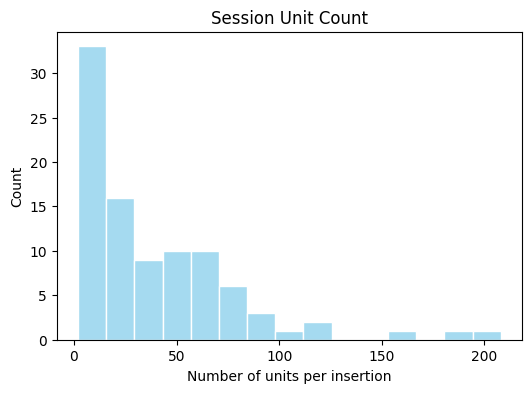

In [38]:
plt.figure(figsize=(6, 4))
ax = sns.histplot(
    data=sessions_vetted['num_units'],  # Normalizes histogram to match KDE scale
    bins=15,       # Auto-selects bin size (or set manually, e.g., bins=30)
    color="skyblue",   # Histogram color
    edgecolor="white", # Edge color for bars
    line_kws={"color": "red", "lw": 2}  # KDE line style
)

# Labels & title
plt.xlabel('Number of units per insertion')
plt.ylabel('Count')
plt.title('Session Unit Count')
# plt.savefig(os.path.join(p.LOGS_DIR, "session_unit_count.png"))# no time to finish this

# generate units log

In [39]:
def generate_units_all(sessions_vetted):
    unit_info_list = []
    for _, session_info in sessions_vetted.iterrows():
        session_id = session_info['id']
        _, _, units = utils.get_session_data(session_id)
        for id, spikes in units.items():
            unit_id = f"{session_id}_unit-{id}"
            spiked_trials = spikes['trial_id'].nunique()
            percent_trials_w_spikes = spiked_trials / session_info['num_trials']
            session_fr = len(spikes) / session_info['length']
            unit_info_dict = {
                'session_id': session_id,
                'id': id,
                'unit_id': unit_id,
                'region': session_info['region'],
                'group': session_info['group'],
                'percent_trials_w_spikes': percent_trials_w_spikes,
                'session_fr': session_fr
            }
            unit_info_list.append(unit_info_dict)
    units_all = pd.DataFrame(unit_info_list)
    return units_all

In [40]:
units_all = generate_units_all(sessions_vetted)
units_all.to_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'))
print(f"{len(units_all)} units")

3620 units


In [41]:
units_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'), index_col=0)

In [42]:
num_units_v1 = units_all[units_all['region'] == 'v1'].shape[0]
num_units_str = units_all[units_all['region'] == 'str'].shape[0]
print(f"Number of units in v1: {num_units_v1}")
print(f"Number of units in str: {num_units_str}")

Number of units in v1: 889
Number of units in str: 2731


Text(0.5, 1.0, 'Percent Trials with Spikes Distribution')

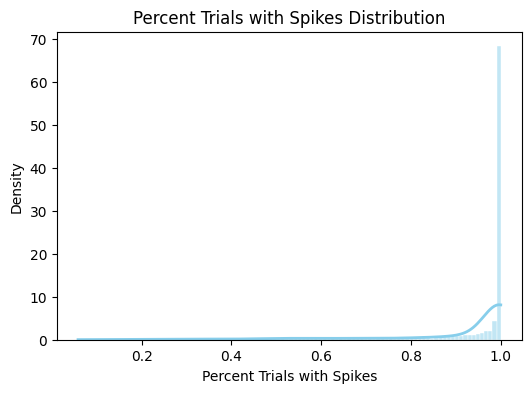

In [43]:
plt.figure(figsize=(6, 4))
ax = sns.histplot(
    data=units_all['percent_trials_w_spikes'],
    kde=True,          # Adds KDE trend line
    stat="density",    # Normalizes histogram to match KDE scale
    bins="auto",       # Auto-selects bin size (or set manually, e.g., bins=30)
    color="skyblue",   # Histogram color
    edgecolor="white", # Edge color for bars
    line_kws={"color": "red", "lw": 2}  # KDE line style
)

# Labels & title
plt.xlabel('Percent Trials with Spikes')
plt.ylabel('Density')
plt.title('Percent Trials with Spikes Distribution')

Text(0.5, 1.0, 'Session Firing Rate Distribution')

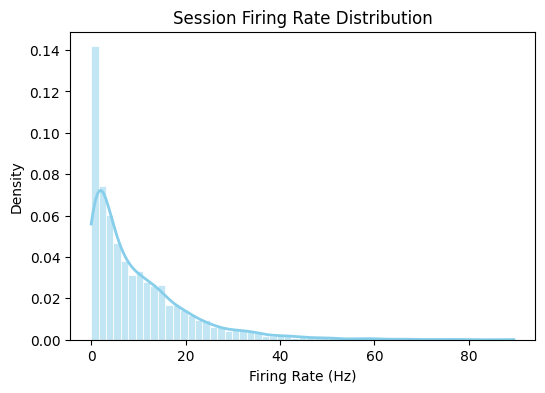

In [44]:
plt.figure(figsize=(6, 4))
ax = sns.histplot(
    data=units_all['session_fr'],
    kde=True,          # Adds KDE trend line
    stat="density",    # Normalizes histogram to match KDE scale
    bins="auto",       # Auto-selects bin size (or set manually, e.g., bins=30)
    color="skyblue",   # Histogram color
    edgecolor="white", # Edge color for bars
    line_kws={"color": "red", "lw": 2}  # KDE line style
)

# Labels & title
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Density')
plt.title('Session Firing Rate Distribution')

In [45]:
units_vetted = units_all.loc[units_all['percent_trials_w_spikes'] >= 0.8]
units_vetted.to_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'))

print(f"{len(units_vetted)} units")

3048 units
